# Bootstrapping RLM with Nightjar

## Setup

In [4]:
import os
from dataclasses import dataclass 
import re
from datetime import datetime
from typing import Tuple, Optional, List, Dict, Any
import time
from tqdm.notebook import tqdm
import ast
from copy import copy, deepcopy
import dateutil
import json
from itertools import combinations

import datasets
import openai
import dotenv
import pandas as pd
import seaborn as sns
import matplotlib.ticker as ticker
import matplotlib.pyplot as plt
import numpy as np
import func_timeout

from nightjarpy import LLMUsage, NJ_TELEMETRY
from nightjarpy.utils import Telemetry
import nightjarpy as nj

dotenv.load_dotenv()

True

In [5]:
@dataclass
class ExampleTelemtry(Telemetry):
    execution_time: Optional[float] = None


### Tasks

In [6]:
N = 50
SEED = 42

#### OOLONG Synth

In [7]:
OOLONG_TASK_LENGTH = 131072
oolong_synth = datasets.load_dataset("oolongbench/oolong-synth")
oolong_synth

Resolving data files:   0%|          | 0/42 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/42 [00:00<?, ?it/s]

DatasetDict({
    validation: Dataset({
        features: ['id', 'context_len', 'dataset', 'context_window_text', 'context_window_text_with_labels', 'question', 'task_group', 'task', 'answer', 'answer_type', 'input_subset', 'num_labels', 'context_window_id'],
        num_rows: 1300
    })
    test: Dataset({
        features: ['id', 'context_len', 'dataset', 'context_window_text', 'context_window_text_with_labels', 'question', 'task_group', 'task', 'answer', 'answer_type', 'input_subset', 'num_labels', 'context_window_id'],
        num_rows: 5200
    })
})

In [8]:
oolong_synth['validation']['context_len']

Column([1024, 1024, 1024, 1024, 1024])

Using the `trec_course` split, following RLM's methodology.

In [9]:
trec_coarse_all = oolong_synth.filter(lambda x: x['dataset'] == 'trec_coarse' and x['context_len'] == OOLONG_TASK_LENGTH)['validation']
trec_coarse_all

Dataset({
    features: ['id', 'context_len', 'dataset', 'context_window_text', 'context_window_text_with_labels', 'question', 'task_group', 'task', 'answer', 'answer_type', 'input_subset', 'num_labels', 'context_window_id'],
    num_rows: 50
})

Subsample dataset

In [10]:
trec_coarse = trec_coarse_all.shuffle(seed=SEED).select(range(N))
trec_coarse

Dataset({
    features: ['id', 'context_len', 'dataset', 'context_window_text', 'context_window_text_with_labels', 'question', 'task_group', 'task', 'answer', 'answer_type', 'input_subset', 'num_labels', 'context_window_id'],
    num_rows: 50
})

Answer parser from https://github.com/abertsch72/oolong/blob/main/src/eval/eval_helpers.py

In [11]:
def synth_attempt_answer_parse(answer):
    parse_confidence = "low"
    if ":" not in answer:  # bad start
        if len(answer) < 20:  # it's short, return the whole thing
            return answer, parse_confidence
        else:
            return answer.split()[-1], parse_confidence
    candidate_answer = answer.split(":")[-1].strip()
    candidate_answer = candidate_answer.replace(
        "*", ""
    )  # OpenAI models like bolding the answer


    candidate_answer = candidate_answer.replace(
        "[", ""
    ) 
    candidate_answer = candidate_answer.replace(
        "]", ""
    )  # Anthropic models like putting the answer in []
    parse_confidence = "med"
    if (
        "User:" in answer
        or "Answer:" in answer
        or "Date:" in answer
        or "Label" in answer
    ):
        parse_confidence = "high"
    if len(candidate_answer) < 20:
        parse_confidence = "vhigh"
    elif "more common" in candidate_answer:
        candidate_answer = "more common"
    elif "less common" in candidate_answer:
        candidate_answer = "less common"
    elif "same frequency" in candidate_answer:
        candidate_answer = "same frequency"

    return candidate_answer, parse_confidence


def synth_process_response(datapoint, output, model):

    score = 0
    gold = (
        ast.literal_eval(datapoint["answer"])[0]
        if "datetime" not in datapoint["answer"]
        else datetime.strptime(datapoint["answer"], "[datetime.date(%Y, %m, %d)]")
    )

    trimmed_output, parse_confidence =  synth_attempt_answer_parse(output)
    if str(trimmed_output) == str(gold):
        score = 1
    elif str(trimmed_output) in ['more common', 'less common', 'same frequency']: # account for these being slightly different wordings
        if str(trimmed_output) in  str(gold):
            score = 1
    elif (
        datapoint["answer_type"] == "ANSWER_TYPE.NUMERIC"
    ):  # partial credit for numbers
        try:
            trimmed_output = int(trimmed_output)
            gold = int(gold)
            score = 0.75 ** (abs(gold - trimmed_output))
        except Exception:
            parse_confidence = "low"  # didn't parse as a number, that's a bad sign
    elif datapoint["answer_type"] == "ANSWER_TYPE.DATE":
        try:
            trimmed_output = dateutil.parser.parse(trimmed_output)
            score = trimmed_output == gold
        except Exception:
            parse_confidence = "low"  # didn't parse as a date, that's a bad sign


    this_output = {
        "id": datapoint["id"],
        "context_window_id": datapoint["context_window_id"],
        "dataset": datapoint["dataset"],
        "model": model,
        "attempted_parse": str(trimmed_output),
        "parse_confidence": parse_confidence,
        "full_answer": output,
        "score": score,
        "answer": str(gold),
    }

    return this_output

## Method setup

In [31]:
model_display = 'openai/gpt-5_medium;openai/gpt-5-mini'

root_model = 'openai/gpt-5'
model_kwargs= {
    'reasoning': {
        'effort': 'medium',
    },
    'max_output_tokens': 8192,
}

# sub_model = None
sub_model = 'openai/gpt-5-mini'
sub_model_kwargs= {
    'reasoning': {
        'effort': 'medium',
    },
    'max_output_tokens': 8192,
}

In [32]:
from nightjarpy.prompts import INTERPRETER_PYTHON_V1_PROMPT, INTERPRETER_PYTHON_NESTED_V0_PROMPT

INTERPRETER_PYTHON_JSON_CONFIG = nj.configs.Config(
    execution_strategy=nj.configs.ExecutionStrategy.INTERPRETER,
    compiler_config=None,
    interpreter_config=nj.configs.InterpreterConfig(
        execution_substrate=nj.configs.ExecutionSubstrate.PYTHON,
        prompt_template=INTERPRETER_PYTHON_V1_PROMPT,
        eager_load=False,
        show_effect_count=False,
        max_effects=30,
    ),
    use_functions=True,
    llm_config=nj.configs.LLMConfig(
        model=root_model,
        tool_choice="required",
        cache=False,
        json_structured_output=True,
        reasoning_effort=model_kwargs['reasoning']['effort'],
        max_tokens=model_kwargs['max_output_tokens'],
    ),
)

INTERPRETER_PYTHON_NESTED_JSON_CONFIG = nj.configs.Config(
    execution_strategy=nj.configs.ExecutionStrategy.INTERPRETER,
    compiler_config=None,
    interpreter_config=nj.configs.InterpreterConfig(
        execution_substrate=nj.configs.ExecutionSubstrate.PYTHON_NESTED,
        prompt_template=INTERPRETER_PYTHON_NESTED_V0_PROMPT,
        eager_load=False,
        show_effect_count=False,
        max_effects=30,
        max_serialize_len=20000,
    ),
    use_functions=True,
    llm_config=nj.configs.LLMConfig(
        model=root_model,
        tool_choice="required",
        cache=False,
        json_structured_output=True,
        reasoning_effort=model_kwargs['reasoning']['effort'],
        max_tokens=model_kwargs['max_output_tokens'],
    ),
    compute_llm_config=nj.configs.LLMConfig(
        model=sub_model,
        tool_choice="required",
        cache=False,
        json_structured_output=True,
        reasoning_effort=sub_model_kwargs['reasoning']['effort'],
        max_tokens=sub_model_kwargs['max_output_tokens'],
    ) if sub_model else None,
)

#### Standard LLM with isolated program state, where context is given as text dump

In [33]:
client = openai.Client(api_key = os.getenv("OPENAI_API_KEY"), project=os.getenv('OPENAI_PROJECT'))

def llm(context: str, question: str) -> Tuple[str, ExampleTelemtry]:
    model = root_model.split('/')[1]

    t1 = time.time()

    res = client.responses.create(
        model=model,
        input=f"{context}\nQuestion: {question}",
        reasoning={
            'effort': model_kwargs['reasoning']['effort'],
        },
        max_output_tokens=model_kwargs['max_output_tokens'],
    )

    t2 = time.time()

    telemetry = ExampleTelemtry(
        llm_usage={
            'rlm.llm': [LLMUsage(
                input_tokens=res.usage.input_tokens if res.usage else 0, 
                cached_input_tokens=res.usage.input_tokens_details.cached_tokens if res.usage else 0,
                output_tokens=res.usage.output_tokens if res.usage else 0,
            )]
        },
        n_tool_calls=0,
        trace={},
        execution_time=t2 - t1,
    )
    answer = res.output_text

    return answer, telemetry

#### RLM with isolated program state, where context is given as is, using the RLM

Make sure `rlm` is installed.

In [34]:
import rlm

In [35]:
def rlm_ips(context: str, question: str) -> Tuple[str, ExampleTelemtry]:
    root_model_name = root_model.split('/')[1]
    sub_model_name = sub_model.split('/')[1]  if sub_model else None

    rlm_client = rlm.RLM(
        backend='openai',
        backend_kwargs={
            'model_name': root_model_name,
            'model_kwargs': model_kwargs,
            "api_key": os.getenv("OPENAI_API_KEY"),
            'project': os.getenv('OPENAI_PROJECT'),
        },
        environment="local",
        environment_kwargs={},
        other_backends=['openai'] if sub_model else None,
        other_backend_kwargs=[{
            'model_name': sub_model_name,
            'model_kwargs': sub_model_kwargs,
            "api_key": os.getenv("OPENAI_API_KEY"),
            'project': os.getenv('OPENAI_PROJECT'),
        }]  if sub_model else None,
        max_depth=1,
        max_iterations=30,
        verbose=False,
    )
    res = rlm_client.completion(
        prompt=context,
        root_prompt=question,
    )
    telemetry = ExampleTelemtry(
        llm_usage={
            'rlm.rlm_ips': [LLMUsage(
                input_tokens=res.usage_summary.model_usage_summaries[model_name].total_input_tokens, 
                output_tokens=res.usage_summary.model_usage_summaries[model_name].total_output_tokens,
                cached_input_tokens=0,
            ) for model_name in res.usage_summary.model_usage_summaries.keys()
            # , LLMUsage(
            #     input_tokens=res.usage_summary.model_usage_summaries[sub_model_name].total_input_tokens, 
            #     output_tokens=res.usage_summary.model_usage_summaries[sub_model_name].total_output_tokens,
            #     cached_input_tokens=0,
            # )
            ]
        },
        n_tool_calls=res.usage_summary.model_usage_summaries[root_model_name].total_calls,
        trace={},
        execution_time=res.execution_time,
    )
    answer = res.response
    return answer, telemetry

#### Shared Program State (No recursive LLM calls), where context is given as is

In [36]:
def sps_str_factory(context: str, question: str) -> Tuple[str, ExampleTelemtry]:
   
    @nj.fn(config=INTERPRETER_PYTHON_JSON_CONFIG, filename='rlm')
    def sps_str(context: str, question: str) -> Tuple[str, ExampleTelemtry]:
        NJ_TELEMETRY.reset()

        t1 = time.time()

        """natural
        Look at <question>, and <context>. Save the answer to <question> as <:answer> as a string in the format specified in <question>
        """

        t2 = time.time()

        telemetry = ExampleTelemtry(
            llm_usage=NJ_TELEMETRY.llm_usage,
            n_tool_calls=NJ_TELEMETRY.n_tool_calls,
            trace=NJ_TELEMETRY.trace,
            execution_time= t2 - t1,
        )
        
        return answer, telemetry
    
    return sps_str(context, question)

#### RLM with shared program state, where context is given as is

In [39]:
def rlm_sps_str_factory(context: str, question: str) -> Tuple[str, ExampleTelemtry]:
    
    @nj.fn(config=INTERPRETER_PYTHON_NESTED_JSON_CONFIG, filename='rlm')
    def rlm_sps_str(context: str, question: str) -> Tuple[str, ExampleTelemtry]:
        NJ_TELEMETRY.reset()

        t1 = time.time()

        """natural
        Look at <question>, and <context>. Save the answer to <question> as <:answer> as a string in the format specified in <question>
        """

        t2 = time.time()

        telemetry = ExampleTelemtry(
            llm_usage=NJ_TELEMETRY.llm_usage,
            n_tool_calls=NJ_TELEMETRY.n_tool_calls,
            trace=NJ_TELEMETRY.trace,
            execution_time= t2 - t1,
        )
        
        return answer, telemetry
    
    return rlm_sps_str(context, question)



## Experiment

In [ ]:
methods = {
    'llm': llm,
    'rlm_ips': rlm_ips,
    'sps_str': sps_str_factory,
    'rlm_sps_str': rlm_sps_str_factory,
}

tasks = {
    'oolong_synth_labels': {
        'dataset': trec_coarse,
        'context_column': 'context_window_text_with_labels',
        'score_fn': synth_process_response,
    },
    'oolong_synth': {
        'dataset': trec_coarse,
        'context_column': 'context_window_text',
        'score_fn': synth_process_response,
    },
}

TASK = 'oolong_synth'
TIMEOUT = 1000
N_SAMPLE = 50
output_file = 'rlm_experiment.jsonl'

results = []
N_SAMPLE = min(N_SAMPLE, max(len(tasks[TASK]['dataset']), N_SAMPLE))
N_SAMPLE

50

In [64]:
if os.path.exists(output_file):
    results_df = pd.read_json(output_file, lines=True)
    results = results_df.to_dict(orient='records')

    already_done = set([
        (x['id'], x['method'], x['model'], x['dataset']) for x in results
    ])
    print(f'Already done {len(already_done)} settings')
    print(f"Finished {len(results_df['id'].unique())} questions")
else:
    already_done = set()

Already done 236 settings
Finished 50 questions


In [65]:

for idx in tqdm(range(N_SAMPLE), desc='Dataset', total=N_SAMPLE):

    example = tasks[TASK]['dataset'][idx] # type: ignore
    context = str(example[tasks[TASK]['context_column']])
    question = str(example['question'])
    score_fn = tasks[TASK]['score_fn']

    for method, method_fn in tqdm(methods.items(), desc="Method", total=len(methods)):
        if (example['id'], method, model_display, TASK) in already_done:
            continue
        
        print(f"Running ID {example['id']}")

        try:
            output, telemetry = func_timeout.func_timeout(TIMEOUT, method_fn, args=(context, question)) # type:ignore
        except Exception as e:
            print(e)
            output = None
            telemetry = ExampleTelemtry()
        except func_timeout.FunctionTimedOut as e:
            print('Timeout')
            output = 'TIMEOUT'
            telemetry = ExampleTelemtry()

        total_usage = telemetry.total_llm_usage()
        eval_res = score_fn(example, output or '', model_display)

        row = {
            'id': example['id'],
            'context_window_id': example['context_window_id'],
            "dataset": TASK,
            'model': model_display,
            'method': method,
            'score': eval_res['score'],
            'parse_confidence': eval_res['parse_confidence'],
            'execution_time': telemetry.execution_time,
            'total_input_tokens': total_usage.input_tokens,
            'cached_input_tokens': total_usage.cached_input_tokens,
            'output_tokens': total_usage.output_tokens,
            'token_details': { k: [x.model_dump() for x in v] for k, v in telemetry.llm_usage.items()},
            'n_tool_calls': telemetry.n_tool_calls,
            'output': output,
            "attempted_parse": eval_res['attempted_parse'],
            'gold_answer': eval_res['answer'],
        }

        results.append(row)

        with open(output_file, 'a') as f:
            f.write(json.dumps(row) + '\n')


Dataset:   0%|          | 0/50 [00:00<?, ?it/s]

Method:   0%|          | 0/1 [00:00<?, ?it/s]

Method:   0%|          | 0/1 [00:00<?, ?it/s]

Method:   0%|          | 0/1 [00:00<?, ?it/s]

Method:   0%|          | 0/1 [00:00<?, ?it/s]

...

Running ID 17000209


Method:   0%|          | 0/1 [00:00<?, ?it/s]

Running ID 17000221


Method:   0%|          | 0/1 [00:00<?, ?it/s]

Running ID 17000216


In [66]:
results = pd.DataFrame(results)


## Results

In [129]:
sns.set_style('whitegrid', {'grid.linestyle': ':'})

In [130]:
output_file = 'rlm_experiment.jsonl'
results = pd.read_json(output_file, lines=True)

In [132]:
results = results[~results['method'].isin(['rlm_sps_llmdata', 'rlm_sh', 'rlm_sps_str_20000'])]

In [133]:
results = results.merge(trec_coarse.to_pandas()[['id', 'context_len']], on='id', how='left')

In [134]:
results.head()

,id,context_window_id,dataset,model,method,score,parse_confidence,execution_time,total_input_tokens,cached_input_tokens,output_tokens,token_details,n_tool_calls,output,attempted_parse,gold_answer,context_len
0,17000213,8,oolong_synth,openai/gpt-5_medium;openai/gpt-5-mini,llm,1.0,high,6.171280,94296,93952.0,335,"{'rlm.llm': [{'input_tokens': 94296, 'output_t...",0,Answer: entity is more common than human being,more common,more common than,131072
1,17000206,6,oolong_synth,openai/gpt-5_medium;openai/gpt-5-mini,llm,0.0,med,13.823667,92391,0.0,627,"{'rlm.llm': [{'input_tokens': 92391, 'output_t...",0,"I can’t produce the exact, non-approximate ans...",- Programmatically classify each question and ...,numeric value,131072
2,17000228,8,oolong_synth,openai/gpt-5_medium;openai/gpt-5-mini,llm,0.0,vhigh,16.104820,94265,0.0,907,"{'rlm.llm': [{'input_tokens': 94265, 'output_t...",0,User: 37367,37367,93824,131072
3,17000255,6,oolong_synth,openai/gpt-5_medium;openai/gpt-5-mini,llm,1.0,high,40.106639,92428,0.0,2447,"{'rlm.llm': [{'input_tokens': 92428, 'output_t...",0,Answer: numeric value is more common than loca...,more common,more common than,131072
4,17000245,6,oolong_synth,openai/gpt-5_medium;openai/gpt-5-mini,llm,1.0,vhigh,39.733595,92414,92032.0,2313,"{'rlm.llm': [{'input_tokens': 92414, 'output_t...",0,Label: abbreviation,abbreviation,abbreviation,131072


In [135]:
score = pd.DataFrame(results.groupby(['model', 'method', 'dataset'])['score'].mean()).reset_index()
score['percent'] = score['score'] * 100
score


,model,method,dataset,score,percent
0,openai/gpt-5_medium;openai/gpt-5-mini,llm,oolong_synth,0.400000,40.000000
1,openai/gpt-5_medium;openai/gpt-5-mini,rlm_ips,oolong_synth,0.466248,46.624779
2,openai/gpt-5_medium;openai/gpt-5-mini,rlm_sps_str,oolong_synth,0.480000,48.000004
3,openai/gpt-5_medium;openai/gpt-5-mini,sps_str,oolong_synth,0.440000,44.000000


/Users/ellieyhc/Documents/Research/nightjarpy/venv/lib/python3.13/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)


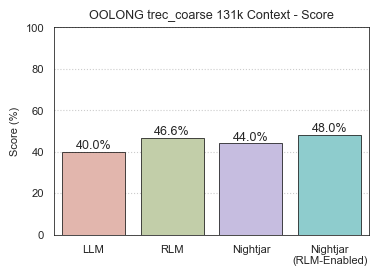

In [ ]:
g = sns.FacetGrid(score,  col='dataset', aspect=1.3)
g.map(sns.barplot, 'method', 'percent', palette=["#ebb0a4","#c4d4a3","#c3b7e6", "#83d6d8"], order=['llm', 'rlm_ips', 'sps_str', 'rlm_sps_str'], edgecolor="black", linewidth=0.5)
g.set_titles(template='OOLONG trec_coarse 131k Context - Score')
for ax in g.axes.flat:
    ax.set_title(ax.get_title(), fontsize=9)
g.set(ylim=(0, 100))
g.set_xticklabels(['LLM', 'RLM', 'Nightjar', 'Nightjar\n(RLM-Enabled)'], fontsize=8)
g.set_yticklabels(fontsize=8)
g.set_xlabels('')
g.set_ylabels('Score (%)', fontsize=8)

for ax in g.axes.flat:
    for c in ax.containers:
        ax.bar_label(c, fmt='%.1f%%', fontsize=9)

for ax in g.axes.flat:
    for spine in ax.spines.values():
        spine.set_color('black')
        spine.set_linewidth(0.5)
        spine.set_linestyle('solid')
        spine.set_visible(True)

plt.savefig('oolong_score.pdf')

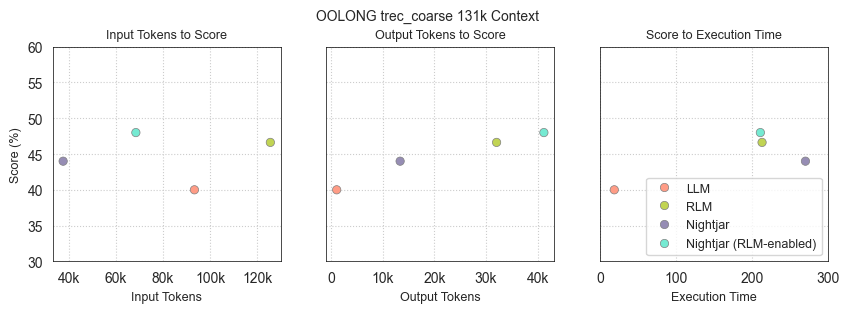

In [ ]:
temp = pd.DataFrame(results.groupby(['model', 'method', 'dataset'])[['score', 'total_input_tokens', 'execution_time', 'output_tokens']].mean()).reset_index()
rename = {
    'llm': 'LLM',
    'rlm_ips': 'RLM',
    'rlm_sps_str': 'Nightjar (RLM-enabled)',
    'sps_str': 'Nightjar',
}
order = ['LLM', 'RLM', 'Nightjar', "Nightjar (RLM-enabled)"]
temp = temp.map(lambda x: rename.get(x, x))
temp['percent'] = temp['score'] * 100

fig, axes = plt.subplots(1, 3, figsize=(10, 2.9), sharey=True)

sns.scatterplot(temp, x='total_input_tokens', y='percent', ax=axes[0], hue='method', palette=['#ff9c86', '#c1d453', '#75ead2', '#968db4'], edgecolor='gray', linewidth=0.5, legend=False)

sns.scatterplot(temp, x='output_tokens', y='percent', ax=axes[1], hue='method', palette=['#ff9c86', '#c1d453', '#75ead2', '#968db4'], edgecolor='gray', linewidth=0.5, legend=False)

sns.scatterplot(temp, x='execution_time', y='percent', ax=axes[2], hue='method', palette=['#ff9c86', '#c1d453', '#75ead2', '#968db4'], edgecolor='gray', linewidth=0.5)

axes[0].set_xlabel('Input Tokens', fontsize=9)
axes[0].set_ylabel('Score (%)', fontsize=9)
axes[0].set_title('Input Tokens to Score', fontsize=9)

axes[1].set_xlabel('Output Tokens', fontsize=9)
axes[1].set_ylabel('Score (%)', fontsize=9)
axes[1].set_title('Output Tokens to Score', fontsize=9)

axes[2].set_xlabel('Execution Time', fontsize=9)
axes[2].set_ylabel('Score (%)', fontsize=9)
axes[2].set_title('Score to Execution Time', fontsize=9)

handles, labels = axes[2].get_legend_handles_labels()
s_handles, s_labels = [], []
for h, l in sorted(list(zip(handles, labels)), key=lambda x: order.index(x[1])):
    s_handles.append(h)
    s_labels.append(l)
axes[2].legend(s_handles, s_labels, fontsize=9, loc='lower right', title='')

import matplotlib.ticker as tkr
for ax in axes.flat:
    ax.set_ylim((30, 60))
    for spine in ax.spines.values():
        spine.set_color('black')
        spine.set_linewidth(0.5)
        spine.set_linestyle('solid')
        spine.set_visible(True)
    
axes[0].xaxis.set_major_formatter(tkr.FuncFormatter(lambda x, pos: f'{x // 1000:.0f}k'))
axes[1].xaxis.set_major_formatter(tkr.FuncFormatter(lambda x, pos: f'{x // 1000:.0f}k' if x >= 1000 else round(x)))
axes[2].set_xlim((0, 300))

fig.suptitle('OOLONG trec_coarse 131k Context', fontsize=10)

plt.subplots_adjust(top=0.85)

fig.savefig('oolong_inp_time.pdf')

In [138]:
temp['execution_time'] / temp[temp['method'] == 'LLM']['execution_time'].values[0]

0     1.000000
1    11.219450
2    11.102479
3    14.219983
Name: execution_time, dtype: float64